Since the pretrained transformer performed quite well and it seemed like there was more improvement to be found have i decided to make use of a larger model, and a larger image size (it is now only downsized to 384 x 384 the same size as the pretrained model was trained on). This should help in keeping more information from the image.

This will however also increase the training time but should show an increase in performance.

Prerequisits

In [ ]:
!pip install -q keras-hub huggingface_hub

In [ ]:
from huggingface_hub import notebook_login
notebook_login()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Libraries

In [ ]:
import os
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from huggingface_hub import login, HfApi
import json

import keras_hub

Configuration

In [ ]:
IMG_HEIGHT = 384
IMG_WIDTH  = 384
BATCH_SIZE = 16
AUTOTUNE   = tf.data.AUTOTUNE

STAGE1_EPOCHS = 100
STAGE2_EPOCHS = 200

STAGE1_LR = 1e-3
STAGE2_LR = 5e-6

# Larger DeiT
VIT_PRESET = "deit_base_distilled_patch16_384_imagenet"

Dataset loading and splitting

In [ ]:
DATASET_DIR = Path("/content/drive/MyDrive/Speciale/dataset/nutrition5k_compactV3")

# Metadata CSV
METADATA_CSV = Path("/content/drive/MyDrive/Speciale/dataset/prepared_overhead_rgb_dataset/dish_carb_split_metadata.csv")

# Output folder for this model
OUTPUT_DIR = Path("/content/drive/MyDrive/Speciale/Models/Model_3_V2_ViT_rgb")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

In [ ]:
df = pd.read_csv(METADATA_CSV)

print(df.head())
print(df["split"].value_counts())

           dish_id  total_carb split source_cafe
0  dish_1556575327      10.618  test       cafe1
1  dish_1557861216       0.000  test       cafe1
2  dish_1557862345       0.000  test       cafe1
3  dish_1557862696       3.850  test       cafe1
4  dish_1557862738       0.000  test       cafe1
split
train    2421
test      507
val       334
Name: count, dtype: int64


In [ ]:
df["image_path"] = df["dish_id"].apply(
    lambda d: str(DATASET_DIR / d / "overhead" / "rgb.png")
)

df["image_exists"] = df["image_path"].apply(lambda p: Path(p).exists())

print("Missing images:", (~df["image_exists"]).sum())

df = df[df["image_exists"]].copy()

print(df["split"].value_counts())
print(df.head())

Missing images: 0
split
train    2421
test      507
val       334
Name: count, dtype: int64
           dish_id  total_carb split source_cafe  \
0  dish_1556575327      10.618  test       cafe1   
1  dish_1557861216       0.000  test       cafe1   
2  dish_1557862345       0.000  test       cafe1   
3  dish_1557862696       3.850  test       cafe1   
4  dish_1557862738       0.000  test       cafe1   

                                          image_path  image_exists  
0  /content/drive/MyDrive/Speciale/dataset/nutrit...          True  
1  /content/drive/MyDrive/Speciale/dataset/nutrit...          True  
2  /content/drive/MyDrive/Speciale/dataset/nutrit...          True  
3  /content/drive/MyDrive/Speciale/dataset/nutrit...          True  
4  /content/drive/MyDrive/Speciale/dataset/nutrit...          True  


In [ ]:
train_df = df[df["split"] == "train"].copy()
val_df   = df[df["split"] == "val"].copy()
test_df  = df[df["split"] == "test"].copy()

print("Train:", len(train_df))
print("Val:  ", len(val_df))
print("Test: ", len(test_df))

Train: 2421
Val:   334
Test:  507


In [ ]:
def load_image_and_label(image_path, label):
    image = tf.io.read_file(image_path)
    image = tf.image.decode_png(image, channels=3)

    image = tf.image.resize_with_pad(
        image,
        target_height=IMG_HEIGHT,
        target_width=IMG_WIDTH,
        method=tf.image.ResizeMethod.BILINEAR,
        antialias=True
    )

    image = tf.cast(image, tf.float32)
    label = tf.cast(label, tf.float32)
    label = tf.expand_dims(label, axis=-1)

    return image, label


def make_dataset(dataframe, batch_size=BATCH_SIZE, shuffle=False):
    image_paths = dataframe["image_path"].values
    labels = dataframe["total_carb"].values.astype("float32")

    ds = tf.data.Dataset.from_tensor_slices((image_paths, labels))

    if shuffle:
        ds = ds.shuffle(buffer_size=len(dataframe), reshuffle_each_iteration=True)

    ds = ds.map(load_image_and_label, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(batch_size)
    ds = ds.prefetch(AUTOTUNE)
    return ds


train_dataset = make_dataset(train_df, batch_size=BATCH_SIZE, shuffle=True)
validation_dataset = make_dataset(val_df, batch_size=BATCH_SIZE, shuffle=False)
test_dataset = make_dataset(test_df, batch_size=BATCH_SIZE, shuffle=False)

Stage 1 architecture

In [ ]:
# Preprocessing layer matched to the DeiT preset
image_converter = keras_hub.layers.ImageConverter.from_preset(VIT_PRESET)

# Pretrained DeiT backbone
backbone = keras_hub.models.Backbone.from_preset(VIT_PRESET)

# Stage 1: freeze backbone
backbone.trainable = False

inputs = keras.Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3), name="rgb_input")

# Preset-specific preprocessing
x = image_converter(inputs)

# Forward through backbone
x = backbone(x)

# Handle possible dict output
if isinstance(x, dict):
    if "sequence_output" in x:
        x = x["sequence_output"]
    else:
        x = list(x.values())[0]

# Token pooling + regression head
x = layers.GlobalAveragePooling1D(name="token_avg_pool")(x)
x = layers.Dropout(0.30, name="dropout_1")(x)
x = layers.Dense(256, activation="relu", name="dense_256")(x)
x = layers.Dropout(0.20, name="dropout_2")(x)
outputs = layers.Dense(1, activation="linear", name="carb_output")(x)

model = keras.Model(inputs, outputs, name="deit_base_384_rgb_carb_regression")

model.summary()

100%|██████████| 617/617 [00:00<00:00, 1.27MB/s]


100%|██████████| 968/968 [00:00<00:00, 1.90MB/s]


100%|██████████| 329M/329M [00:02<00:00, 159MB/s]


Model: "deit_base_384_rgb_carb_regression"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rgb_input (InputLayer)          │ (None, 384, 384, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dei_t_image_converter           │ (None, 384, 384, 3)    │             0 │
│ (DeiTImageConverter)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dei_t_backbone (DeiTBackbone)   │ (None, 578, 768)       │    86,092,032 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ token_avg_pool                  │ (None, 768)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 768)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_256 (Dense)               │ (None, 256)            │       196,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ carb_output (Dense)             │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 86,289,153 (329.17 MB)

 Trainable params: 197,121 (770.00 KB)

 Non-trainable params: 86,092,032 (328.42 MB)

In [ ]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=STAGE1_LR),
    loss="mse",
    metrics=[
        keras.metrics.MeanAbsoluteError(name="mae"),
        keras.metrics.MeanSquaredError(name="mse")
    ],
    jit_compile=False
)

In [ ]:
stage1_callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath=str(OUTPUT_DIR / "best_model_stage1.weights.h5"),
        monitor="val_loss",
        save_best_only=True,
        save_weights_only=True,
        mode="min",
        verbose=1
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=50,
        mode="min",
        restore_best_weights=True,
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=35,
        min_lr=1e-6,
        mode="min",
        verbose=1
    )
]

In [ ]:
history_stage1 = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=STAGE1_EPOCHS,
    callbacks=stage1_callbacks
)

Epoch 1/100
152/152 ━━━━━━━━━━━━━━━━━━━━ 0s 400ms/step - loss: 620.1461 - mae: 12.4072 - mse: 620.1461
Epoch 1: val_loss improved from None to 139.57625, saving model to /content/drive/MyDrive/Speciale/Models/Model_3_V2_ViT_rgb/best_model_stage1.weights.h5

Epoch 1: finished saving model to /content/drive/MyDrive/Speciale/Models/Model_3_V2_ViT_rgb/best_model_stage1.weights.h5
152/152 ━━━━━━━━━━━━━━━━━━━━ 86s 487ms/step - loss: 485.7767 - mae: 11.2798 - mse: 485.7767 - val_loss: 139.5762 - val_mae: 9.0771 - val_mse: 139.5762 - learning_rate: 0.0010
Epoch 2/100
151/152 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step - loss: 275.1010 - mae: 9.5145 - mse: 275.1010
Epoch 2: val_loss improved from 139.57625 to 116.55263, saving model to /content/drive/MyDrive/Speciale/Models/Model_3_V2_ViT_rgb/best_model_stage1.weights.h5

Epoch 2: finished saving model to /content/drive/MyDrive/Speciale/Models/Model_3_V2_ViT_rgb/best_model_stage1.weights.h5
152/152 ━━━━━━━━━━━━━━━━━━━━ 25s 166ms/step - loss: 425.8225 - 

Evaluating best stage 1 on test set

In [ ]:
stage1_best_path = OUTPUT_DIR / "best_model_stage1.weights.h5"

model.load_weights(str(stage1_best_path))
stage1_test_results = model.evaluate(test_dataset, return_dict=True, verbose=1)

print("Stage 1 test results:")
for k, v in stage1_test_results.items():
    print(f"{k}: {v:.4f}")

32/32 ━━━━━━━━━━━━━━━━━━━━ 15s 445ms/step - loss: 94.6982 - mae: 6.4954 - mse: 94.6982
Stage 1 test results:
loss: 94.6982
mae: 6.4954
mse: 94.6982


Stage 2 architecture and training (Instead of 25% it is now 30% which becomes unfrozen and avaliable to train on)

In [ ]:
# Load best stage 1 weights first
model.load_weights(str(OUTPUT_DIR / "best_model_stage1.weights.h5"))

# Unfreeze backbone
backbone.trainable = True

# Freeze early layers, unfreeze later layers
num_layers = len(backbone.layers)
freeze_until = int(num_layers * 0.70)  # freeze first 70%, train last 30%

for i, layer in enumerate(backbone.layers):
    layer.trainable = (i >= freeze_until)

print(f"Backbone layers: {num_layers}")
print(f"Frozen layers:   {freeze_until}")
print(f"Trainable later layers: {num_layers - freeze_until}")

Backbone layers: 3
Frozen layers:   2
Trainable later layers: 1


In [ ]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=STAGE2_LR),
    loss="mse",
    metrics=[
        keras.metrics.MeanAbsoluteError(name="mae"),
        keras.metrics.MeanSquaredError(name="mse")
    ],
    jit_compile=False
)

In [ ]:
stage2_callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath=str(OUTPUT_DIR / "best_model_stage2.weights.h5"),
        monitor="val_loss",
        save_best_only=True,
        save_weights_only=True,
        mode="min",
        verbose=1
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=100,
        mode="min",
        restore_best_weights=True,
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=75,
        min_lr=1e-7,
        mode="min",
        verbose=1
    )
]

In [ ]:
history_stage2 = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=STAGE2_EPOCHS,
    callbacks=stage2_callbacks
)

Epoch 1/200
152/152 ━━━━━━━━━━━━━━━━━━━━ 0s 283ms/step - loss: 269.2348 - mae: 6.3215 - mse: 269.2348
Epoch 1: val_loss improved from None to 90.51316, saving model to /content/drive/MyDrive/Speciale/Models/Model_3_V2_ViT_rgb/best_model_stage2.weights.h5

Epoch 1: finished saving model to /content/drive/MyDrive/Speciale/Models/Model_3_V2_ViT_rgb/best_model_stage2.weights.h5
152/152 ━━━━━━━━━━━━━━━━━━━━ 81s 333ms/step - loss: 387.2262 - mae: 6.9388 - mse: 387.2262 - val_loss: 90.5132 - val_mae: 6.8249 - val_mse: 90.5132 - learning_rate: 5.0000e-06
Epoch 2/200
152/152 ━━━━━━━━━━━━━━━━━━━━ 0s 303ms/step - loss: 122.9594 - mae: 6.1265 - mse: 122.9594
Epoch 2: val_loss did not improve from 90.51316
152/152 ━━━━━━━━━━━━━━━━━━━━ 49s 320ms/step - loss: 321.6401 - mae: 6.5092 - mse: 321.6401 - val_loss: 327.1574 - val_mae: 8.0077 - val_mse: 327.1574 - learning_rate: 5.0000e-06
Epoch 3/200
152/152 ━━━━━━━━━━━━━━━━━━━━ 0s 283ms/step - loss: 187.7247 - mae: 6.9993 - mse: 187.7247
Epoch 3: val_loss

Loading best stage 2 model and evaluating on the test set

In [ ]:
stage2_best_path = OUTPUT_DIR / "best_model_stage2.weights.h5"

model.load_weights(str(stage2_best_path))
stage2_test_results = model.evaluate(test_dataset, return_dict=True, verbose=1)

print("Stage 2 test results:")
for k, v in stage2_test_results.items():
    print(f"{k}: {v:.4f}")

32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 109ms/step - loss: 62.9580 - mae: 5.3268 - mse: 62.9580
Stage 2 test results:
loss: 62.9580
mae: 5.3268
mse: 62.9580


Plotting training and validation curves

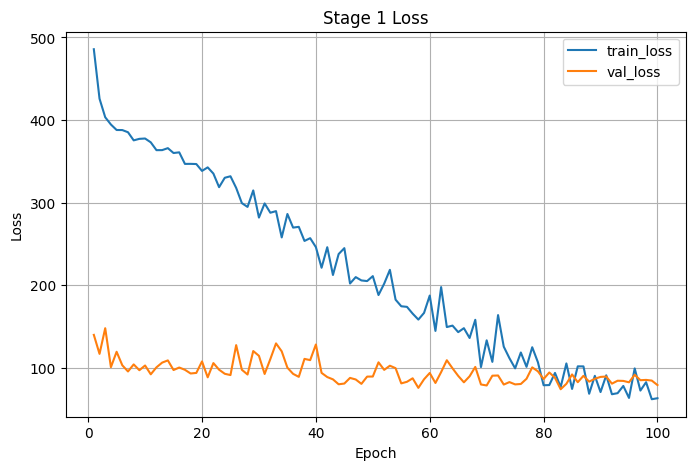

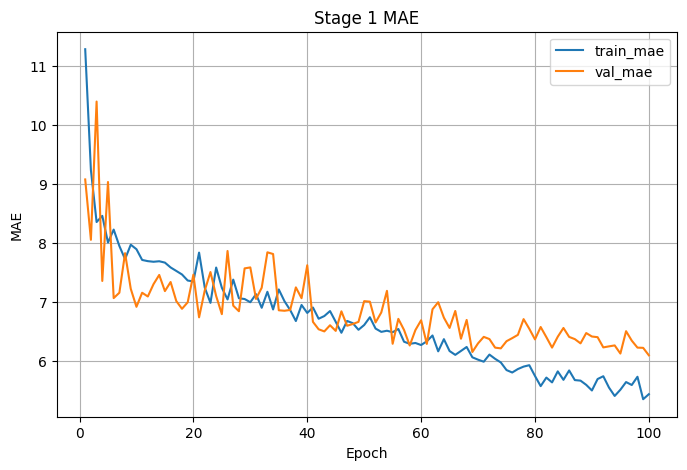

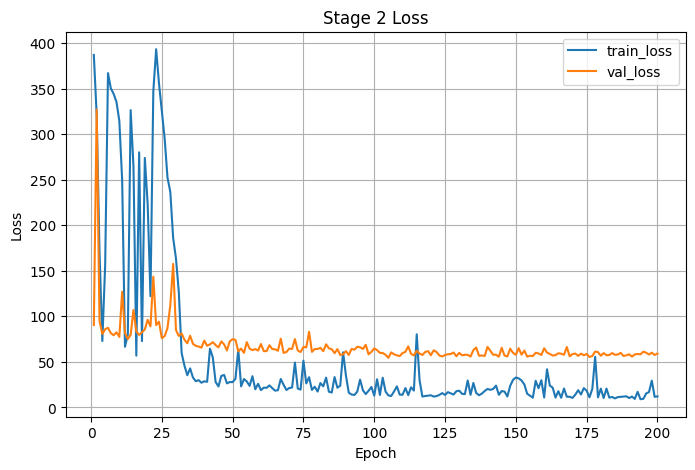

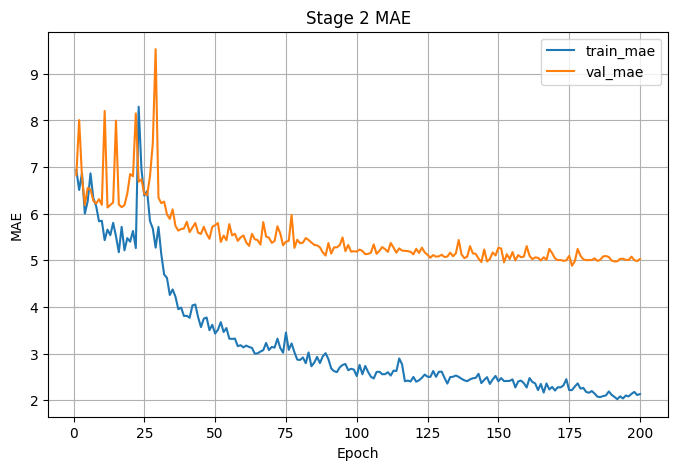

In [ ]:
def plot_history(history, title_prefix=""):
    hist = history.history
    epochs = range(1, len(hist["loss"]) + 1)

    plt.figure(figsize=(8, 5))
    plt.plot(epochs, hist["loss"], label="train_loss")
    plt.plot(epochs, hist["val_loss"], label="val_loss")
    plt.title(f"{title_prefix} Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(epochs, hist["mae"], label="train_mae")
    plt.plot(epochs, hist["val_mae"], label="val_mae")
    plt.title(f"{title_prefix} MAE")
    plt.xlabel("Epoch")
    plt.ylabel("MAE")
    plt.legend()
    plt.grid(True)
    plt.show()


plot_history(history_stage1, "Stage 1")
plot_history(history_stage2, "Stage 2")

Comparrison between stage 1 and stage 2

In [ ]:
comparison_df = pd.DataFrame([
    {
        "stage": "stage_1",
        "test_loss": stage1_test_results.get("loss"),
        "test_mae": stage1_test_results.get("mae"),
        "test_mse": stage1_test_results.get("mse"),
    },
    {
        "stage": "stage_2",
        "test_loss": stage2_test_results.get("loss"),
        "test_mae": stage2_test_results.get("mae"),
        "test_mse": stage2_test_results.get("mse"),
    }
])

print(comparison_df)
comparison_df.to_csv(OUTPUT_DIR / "stage_test_comparison.csv", index=False)

     stage  test_loss  test_mae   test_mse
0  stage_1  94.698196  6.495400  94.698196
1  stage_2  62.958038  5.326849  62.958038


Saving final model

In [ ]:
# Load the best stage 2 weights before saving final model
model.load_weights(str(stage2_best_path))

# Full Keras model
final_keras_path = OUTPUT_DIR / "final_model.keras"
model.save(final_keras_path)

export_dir = OUTPUT_DIR / "saved_model_export"
model.export(export_dir)

print("Saved .keras model to:", final_keras_path)
print("Exported SavedModel to:", export_dir)

Saved artifact at '/content/drive/MyDrive/Speciale/Models/Model_3_V2_ViT_rgb/saved_model_export'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 384, 384, 3), dtype=tf.float32, name='rgb_input')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  132242808208272: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132242808208080: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132242808207696: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132242808207120: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132242808209040: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132242808208464: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132239522152912: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132239522153104: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132239522153680: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132239522154832: TensorSpec

Comparing stage 1 and stage 2 against actual values

In [ ]:
test_eval_df = test_df.copy().reset_index(drop=True)

print(test_eval_df.head())
print("Test rows:", len(test_eval_df))

           dish_id  total_carb split source_cafe  \
0  dish_1556575327      10.618  test       cafe1   
1  dish_1557861216       0.000  test       cafe1   
2  dish_1557862345       0.000  test       cafe1   
3  dish_1557862696       3.850  test       cafe1   
4  dish_1557862738       0.000  test       cafe1   

                                          image_path  image_exists  
0  /content/drive/MyDrive/Speciale/dataset/nutrit...          True  
1  /content/drive/MyDrive/Speciale/dataset/nutrit...          True  
2  /content/drive/MyDrive/Speciale/dataset/nutrit...          True  
3  /content/drive/MyDrive/Speciale/dataset/nutrit...          True  
4  /content/drive/MyDrive/Speciale/dataset/nutrit...          True  
Test rows: 507


In [ ]:
def predict_with_checkpoint(model, checkpoint_path, dataset, base_df, pred_col_name):
    # Load weights
    model.load_weights(str(checkpoint_path))

    # Predict
    preds = model.predict(dataset, verbose=1)

    # Flatten predictions safely
    preds = np.array(preds).reshape(-1)

    # Copy dataframe and attach predictions
    out_df = base_df.copy().reset_index(drop=True)
    out_df[pred_col_name] = preds
    out_df[f"error_{pred_col_name}"] = out_df[pred_col_name] - out_df["total_carb"]
    out_df[f"abs_error_{pred_col_name}"] = np.abs(out_df[f"error_{pred_col_name}"])

    return out_df

In [ ]:
stage1_best_path = OUTPUT_DIR / "best_model_stage1.weights.h5"
stage2_best_path = OUTPUT_DIR / "best_model_stage2.weights.h5"

# Stage 1 predictions
stage1_pred_df = predict_with_checkpoint(
    model=model,
    checkpoint_path=stage1_best_path,
    dataset=test_dataset,
    base_df=test_eval_df,
    pred_col_name="pred_stage1"
)

# Stage 2 predictions
stage2_pred_df = predict_with_checkpoint(
    model=model,
    checkpoint_path=stage2_best_path,
    dataset=test_dataset,
    base_df=test_eval_df,
    pred_col_name="pred_stage2"
)

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 398 variables whereas the saved optimizer has 10 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


32/32 ━━━━━━━━━━━━━━━━━━━━ 7s 157ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 110ms/step


In [ ]:
comparison_predictions_df = stage1_pred_df[[
    "dish_id",
    "image_path",
    "total_carb",
    "pred_stage1",
    "error_pred_stage1",
    "abs_error_pred_stage1"
]].copy()

comparison_predictions_df["pred_stage2"] = stage2_pred_df["pred_stage2"].values
comparison_predictions_df["error_pred_stage2"] = stage2_pred_df["error_pred_stage2"].values
comparison_predictions_df["abs_error_pred_stage2"] = stage2_pred_df["abs_error_pred_stage2"].values

# Improvement: positive means stage 2 improved over stage 1
comparison_predictions_df["abs_error_improvement"] = (
    comparison_predictions_df["abs_error_pred_stage1"]
    - comparison_predictions_df["abs_error_pred_stage2"]
)

print(comparison_predictions_df.head())

           dish_id                                         image_path  \
0  dish_1556575327  /content/drive/MyDrive/Speciale/dataset/nutrit...   
1  dish_1557861216  /content/drive/MyDrive/Speciale/dataset/nutrit...   
2  dish_1557862345  /content/drive/MyDrive/Speciale/dataset/nutrit...   
3  dish_1557862696  /content/drive/MyDrive/Speciale/dataset/nutrit...   
4  dish_1557862738  /content/drive/MyDrive/Speciale/dataset/nutrit...   

   total_carb  pred_stage1  error_pred_stage1  abs_error_pred_stage1  \
0      10.618    16.628820           6.010820               6.010820   
1       0.000    -0.921993          -0.921993               0.921993   
2       0.000     1.334737           1.334737               1.334737   
3       3.850     4.781311           0.931311               0.931311   
4       0.000     6.093148           6.093148               6.093148   

   pred_stage2  error_pred_stage2  abs_error_pred_stage2  \
0    11.951994           1.333994               1.333994   
1     1.

In [ ]:
predictions_csv_path = OUTPUT_DIR / "test_predictions_stage1_vs_stage2.csv"
comparison_predictions_df.to_csv(predictions_csv_path, index=False)

print("Saved full prediction comparison CSV to:")
print(predictions_csv_path)

Saved full prediction comparison CSV to:
/content/drive/MyDrive/Speciale/Models/Model_3_V2_ViT_rgb/test_predictions_stage1_vs_stage2.csv


In [ ]:
top10_best_stage1 = comparison_predictions_df.sort_values(
    by="abs_error_pred_stage1", ascending=True
).head(10)

top10_worst_stage1 = comparison_predictions_df.sort_values(
    by="abs_error_pred_stage1", ascending=False
).head(10)

print("\nTop 10 BEST dishes - Stage 1")
display(top10_best_stage1)

print("\nTop 10 WORST dishes - Stage 1")
display(top10_worst_stage1)


Top 10 BEST dishes - Stage 1


,dish_id,image_path,total_carb,pred_stage1,error_pred_stage1,abs_error_pred_stage1,pred_stage2,error_pred_stage2,abs_error_pred_stage2,abs_error_improvement
367,dish_1564687013,/content/drive/MyDrive/Speciale/dataset/nutrit...,14.725341,14.729881,0.004540,0.004540,14.635502,-0.089839,0.089839,-0.085299
485,dish_1566920304,/content/drive/MyDrive/Speciale/dataset/nutrit...,3.990000,3.999823,0.009823,0.009823,6.089432,2.099432,2.099432,-2.089609
7,dish_1557936599,/content/drive/MyDrive/Speciale/dataset/nutrit...,4.410000,4.452680,0.042680,0.042680,4.523834,0.113834,0.113834,-0.071155
483,dish_1566851677,/content/drive/MyDrive/Speciale/dataset/nutrit...,45.332054,45.376884,0.044830,0.044830,39.065865,-6.266189,6.266189,-6.221359
375,dish_1564773826,/content/drive/MyDrive/Speciale/dataset/nutrit...,2.184000,2.264316,0.080316,0.080316,2.764694,0.580694,0.580694,-0.500378
413,dish_1565711498,/content/drive/MyDrive/Speciale/dataset/nutrit...,10.568151,10.479813,-0.088338,0.088338,8.605571,-1.962580,1.962580,-1.874242
32,dish_1558113430,/content/drive/MyDrive/Speciale/dataset/nutrit...,1.484000,1.585553,0.101553,0.101553,0.680227,-0.803773,0.803773,-0.702219
499,dish_1568305198,/content/drive/MyDrive/Speciale/dataset/nutrit...,2.542000,2.645638,0.103638,0.103638,4.635389,2.093389,2.093389,-1.989751
269,dish_1562700496,/content/drive/MyDrive/Speciale/dataset/nutrit...,6.200000,6.311322,0.111322,0.111322,6.009499,-0.190501,0.190501,-0.079179
462,dish_1566587182,/content/drive/MyDrive/Speciale/dataset/nutrit...,22.501673,22.388710,-0.112963,0.112963,21.150869,-1.350804,1.350804,-1.237841



Top 10 WORST dishes - Stage 1


,dish_id,image_path,total_carb,pred_stage1,error_pred_stage1,abs_error_pred_stage1,pred_stage2,error_pred_stage2,abs_error_pred_stage2,abs_error_improvement
218,dish_1561654374,/content/drive/MyDrive/Speciale/dataset/nutrit...,13.121208,85.275452,72.154244,72.154244,16.427202,3.305994,3.305994,68.848249
454,dish_1566501594,/content/drive/MyDrive/Speciale/dataset/nutrit...,54.281998,14.810989,-39.471009,39.471009,22.411684,-31.870314,31.870314,7.600695
178,dish_1560801020,/content/drive/MyDrive/Speciale/dataset/nutrit...,61.690983,23.622747,-38.068236,38.068236,31.687899,-30.003084,30.003084,8.065151
179,dish_1560801041,/content/drive/MyDrive/Speciale/dataset/nutrit...,63.245892,25.787598,-37.458294,37.458294,30.661999,-32.583893,32.583893,4.874401
177,dish_1560800988,/content/drive/MyDrive/Speciale/dataset/nutrit...,61.249092,24.086935,-37.162157,37.162157,30.835749,-30.413343,30.413343,6.748814
446,dish_1566328805,/content/drive/MyDrive/Speciale/dataset/nutrit...,85.054001,50.129559,-34.924442,34.924442,57.222527,-27.831474,27.831474,7.092968
447,dish_1566328831,/content/drive/MyDrive/Speciale/dataset/nutrit...,85.809998,52.667633,-33.142365,33.142365,58.576302,-27.233696,27.233696,5.908669
466,dish_1566590056,/content/drive/MyDrive/Speciale/dataset/nutrit...,63.927059,31.732798,-32.194261,32.194261,33.738403,-30.188656,30.188656,2.005606
325,dish_1563566909,/content/drive/MyDrive/Speciale/dataset/nutrit...,46.750000,16.035746,-30.714254,30.714254,27.331457,-19.418543,19.418543,11.295712
338,dish_1563909580,/content/drive/MyDrive/Speciale/dataset/nutrit...,74.144119,43.511120,-30.632999,30.632999,52.113106,-22.031013,22.031013,8.601986


In [ ]:
top10_best_stage2 = comparison_predictions_df.sort_values(
    by="abs_error_pred_stage2", ascending=True
).head(10)

top10_worst_stage2 = comparison_predictions_df.sort_values(
    by="abs_error_pred_stage2", ascending=False
).head(10)

print("\nTop 10 BEST dishes - Stage 2")
display(top10_best_stage2)

print("\nTop 10 WORST dishes - Stage 2")
display(top10_worst_stage2)


Top 10 BEST dishes - Stage 2


,dish_id,image_path,total_carb,pred_stage1,error_pred_stage1,abs_error_pred_stage1,pred_stage2,error_pred_stage2,abs_error_pred_stage2,abs_error_improvement
144,dish_1559934477,/content/drive/MyDrive/Speciale/dataset/nutrit...,2.451000,4.453207,2.002207,2.002207,2.463828,0.012828,0.012828,1.989380
274,dish_1562703408,/content/drive/MyDrive/Speciale/dataset/nutrit...,32.833611,27.410954,-5.422657,5.422657,32.848785,0.015174,0.015174,5.407483
52,dish_1558376734,/content/drive/MyDrive/Speciale/dataset/nutrit...,2.520000,3.731107,1.211107,1.211107,2.549357,0.029357,0.029357,1.181750
216,dish_1561654326,/content/drive/MyDrive/Speciale/dataset/nutrit...,7.079548,10.071499,2.991951,2.991951,7.038739,-0.040809,0.040809,2.951142
357,dish_1564428102,/content/drive/MyDrive/Speciale/dataset/nutrit...,4.446124,1.802988,-2.643136,2.643136,4.397480,-0.048644,0.048644,2.594491
210,dish_1561577848,/content/drive/MyDrive/Speciale/dataset/nutrit...,6.037907,7.109823,1.071916,1.071916,5.988235,-0.049672,0.049672,1.022244
377,dish_1564773876,/content/drive/MyDrive/Speciale/dataset/nutrit...,9.881201,10.518166,0.636965,0.636965,9.826956,-0.054245,0.054245,0.582719
187,dish_1560975572,/content/drive/MyDrive/Speciale/dataset/nutrit...,16.068001,17.513330,1.445329,1.445329,16.138048,0.070047,0.070047,1.375282
228,dish_1561662869,/content/drive/MyDrive/Speciale/dataset/nutrit...,10.282766,17.037071,6.754305,6.754305,10.207865,-0.074901,0.074901,6.679404
367,dish_1564687013,/content/drive/MyDrive/Speciale/dataset/nutrit...,14.725341,14.729881,0.004540,0.004540,14.635502,-0.089839,0.089839,-0.085299



Top 10 WORST dishes - Stage 2


,dish_id,image_path,total_carb,pred_stage1,error_pred_stage1,abs_error_pred_stage1,pred_stage2,error_pred_stage2,abs_error_pred_stage2,abs_error_improvement
179,dish_1560801041,/content/drive/MyDrive/Speciale/dataset/nutrit...,63.245892,25.787598,-37.458294,37.458294,30.661999,-32.583893,32.583893,4.874401
149,dish_1560367952,/content/drive/MyDrive/Speciale/dataset/nutrit...,45.956913,17.126066,-28.830847,28.830847,13.772824,-32.184089,32.184089,-3.353242
454,dish_1566501594,/content/drive/MyDrive/Speciale/dataset/nutrit...,54.281998,14.810989,-39.471009,39.471009,22.411684,-31.870314,31.870314,7.600695
177,dish_1560800988,/content/drive/MyDrive/Speciale/dataset/nutrit...,61.249092,24.086935,-37.162157,37.162157,30.835749,-30.413343,30.413343,6.748814
466,dish_1566590056,/content/drive/MyDrive/Speciale/dataset/nutrit...,63.927059,31.732798,-32.194261,32.194261,33.738403,-30.188656,30.188656,2.005606
178,dish_1560801020,/content/drive/MyDrive/Speciale/dataset/nutrit...,61.690983,23.622747,-38.068236,38.068236,31.687899,-30.003084,30.003084,8.065151
446,dish_1566328805,/content/drive/MyDrive/Speciale/dataset/nutrit...,85.054001,50.129559,-34.924442,34.924442,57.222527,-27.831474,27.831474,7.092968
447,dish_1566328831,/content/drive/MyDrive/Speciale/dataset/nutrit...,85.809998,52.667633,-33.142365,33.142365,58.576302,-27.233696,27.233696,5.908669
150,dish_1560367980,/content/drive/MyDrive/Speciale/dataset/nutrit...,47.243912,24.666031,-22.577881,22.577881,20.215836,-27.028076,27.028076,-4.450195
445,dish_1566328776,/content/drive/MyDrive/Speciale/dataset/nutrit...,78.293999,48.486046,-29.807953,29.807953,54.101086,-24.192913,24.192913,5.615040


In [ ]:
top10_most_improved = comparison_predictions_df.sort_values(
    by="abs_error_improvement", ascending=False
).head(10)

top10_most_worsened = comparison_predictions_df.sort_values(
    by="abs_error_improvement", ascending=True
).head(10)

print("\nTop 10 MOST IMPROVED dishes from Stage 1 to Stage 2")
display(top10_most_improved)

print("\nTop 10 MOST WORSENED dishes from Stage 1 to Stage 2")
display(top10_most_worsened)


Top 10 MOST IMPROVED dishes from Stage 1 to Stage 2


,dish_id,image_path,total_carb,pred_stage1,error_pred_stage1,abs_error_pred_stage1,pred_stage2,error_pred_stage2,abs_error_pred_stage2,abs_error_improvement
218,dish_1561654374,/content/drive/MyDrive/Speciale/dataset/nutrit...,13.121208,85.275452,72.154244,72.154244,16.427202,3.305994,3.305994,68.848249
342,dish_1563984242,/content/drive/MyDrive/Speciale/dataset/nutrit...,36.819611,65.859543,29.039932,29.039932,47.353424,10.533813,10.533813,18.506119
343,dish_1563984296,/content/drive/MyDrive/Speciale/dataset/nutrit...,44.607613,70.326431,25.718818,25.718818,55.855579,11.247966,11.247966,14.470852
431,dish_1565898230,/content/drive/MyDrive/Speciale/dataset/nutrit...,19.731150,35.110241,15.379091,15.379091,22.120033,2.388883,2.388883,12.990208
11,dish_1557937157,/content/drive/MyDrive/Speciale/dataset/nutrit...,14.700001,32.983494,18.283493,18.283493,20.751030,6.051029,6.051029,12.232464
296,dish_1562963325,/content/drive/MyDrive/Speciale/dataset/nutrit...,65.333321,49.220825,-16.112496,16.112496,60.780933,-4.552388,4.552388,11.560108
325,dish_1563566909,/content/drive/MyDrive/Speciale/dataset/nutrit...,46.750000,16.035746,-30.714254,30.714254,27.331457,-19.418543,19.418543,11.295712
423,dish_1565894889,/content/drive/MyDrive/Speciale/dataset/nutrit...,33.294998,15.247662,-18.047336,18.047336,26.416197,-6.878801,6.878801,11.168535
201,dish_1561405411,/content/drive/MyDrive/Speciale/dataset/nutrit...,25.675440,13.922449,-11.752991,11.752991,26.761126,1.085686,1.085686,10.667305
441,dish_1566316726,/content/drive/MyDrive/Speciale/dataset/nutrit...,25.365391,39.384537,14.019146,14.019146,28.783163,3.417772,3.417772,10.601374



Top 10 MOST WORSENED dishes from Stage 1 to Stage 2


,dish_id,image_path,total_carb,pred_stage1,error_pred_stage1,abs_error_pred_stage1,pred_stage2,error_pred_stage2,abs_error_pred_stage2,abs_error_improvement
189,dish_1560975628,/content/drive/MyDrive/Speciale/dataset/nutrit...,32.350925,35.596260,3.245335,3.245335,53.654289,21.303364,21.303364,-18.058029
174,dish_1560526552,/content/drive/MyDrive/Speciale/dataset/nutrit...,28.019247,31.509132,3.489885,3.489885,45.240799,17.221552,17.221552,-13.731667
173,dish_1560526530,/content/drive/MyDrive/Speciale/dataset/nutrit...,26.787249,26.505131,-0.282118,0.282118,39.595444,12.808195,12.808195,-12.526076
287,dish_1562788568,/content/drive/MyDrive/Speciale/dataset/nutrit...,46.917168,39.429733,-7.487435,7.487435,27.496994,-19.420174,19.420174,-11.932739
172,dish_1560526514,/content/drive/MyDrive/Speciale/dataset/nutrit...,26.031246,27.446218,1.414972,1.414972,38.932007,12.900761,12.900761,-11.485788
374,dish_1564689219,/content/drive/MyDrive/Speciale/dataset/nutrit...,44.726837,34.770790,-9.956047,9.956047,23.991131,-20.735706,20.735706,-10.779659
192,dish_1561147997,/content/drive/MyDrive/Speciale/dataset/nutrit...,20.639935,21.908699,1.268764,1.268764,30.484573,9.844638,9.844638,-8.575874
291,dish_1562790855,/content/drive/MyDrive/Speciale/dataset/nutrit...,23.783417,24.669884,0.886467,0.886467,32.655384,8.871967,8.871967,-7.985500
193,dish_1561148021,/content/drive/MyDrive/Speciale/dataset/nutrit...,23.611561,27.136482,3.524921,3.524921,34.757545,11.145984,11.145984,-7.621063
469,dish_1566838351,/content/drive/MyDrive/Speciale/dataset/nutrit...,48.034000,42.679966,-5.354034,5.354034,35.237320,-12.796680,12.796680,-7.442646


In [ ]:
top10_best_stage1.to_csv(OUTPUT_DIR / "top10_best_stage1.csv", index=False)
top10_worst_stage1.to_csv(OUTPUT_DIR / "top10_worst_stage1.csv", index=False)

top10_best_stage2.to_csv(OUTPUT_DIR / "top10_best_stage2.csv", index=False)
top10_worst_stage2.to_csv(OUTPUT_DIR / "top10_worst_stage2.csv", index=False)

top10_most_improved.to_csv(OUTPUT_DIR / "top10_most_improved_stage2_vs_stage1.csv", index=False)
top10_most_worsened.to_csv(OUTPUT_DIR / "top10_most_worsened_stage2_vs_stage1.csv", index=False)

print("Saved all top-10 CSV files.")

Saved all top-10 CSV files.


In [ ]:
preview_df = comparison_predictions_df.copy()

numeric_cols = [
    "total_carb",
    "pred_stage1",
    "error_pred_stage1",
    "abs_error_pred_stage1",
    "pred_stage2",
    "error_pred_stage2",
    "abs_error_pred_stage2",
    "abs_error_improvement"
]

preview_df[numeric_cols] = preview_df[numeric_cols].round(2)

display(preview_df.head(20))

,dish_id,image_path,total_carb,pred_stage1,error_pred_stage1,abs_error_pred_stage1,pred_stage2,error_pred_stage2,abs_error_pred_stage2,abs_error_improvement
0,dish_1556575327,/content/drive/MyDrive/Speciale/dataset/nutrit...,10.62,16.629999,6.01,6.01,11.950000,1.33,1.33,4.68
1,dish_1557861216,/content/drive/MyDrive/Speciale/dataset/nutrit...,0.00,-0.920000,-0.92,0.92,1.510000,1.51,1.51,-0.58
2,dish_1557862345,/content/drive/MyDrive/Speciale/dataset/nutrit...,0.00,1.330000,1.33,1.33,1.850000,1.85,1.85,-0.52
3,dish_1557862696,/content/drive/MyDrive/Speciale/dataset/nutrit...,3.85,4.780000,0.93,0.93,4.020000,0.17,0.17,0.76
4,dish_1557862738,/content/drive/MyDrive/Speciale/dataset/nutrit...,0.00,6.090000,6.09,6.09,3.240000,3.24,3.24,2.86
5,dish_1557862783,/content/drive/MyDrive/Speciale/dataset/nutrit...,3.85,21.450001,17.60,17.60,14.590000,10.74,10.74,6.86
6,dish_1557936555,/content/drive/MyDrive/Speciale/dataset/nutrit...,1.15,1.850000,0.70,0.70,2.240000,1.09,1.09,-0.39
7,dish_1557936599,/content/drive/MyDrive/Speciale/dataset/nutrit...,4.41,4.450000,0.04,0.04,4.520000,0.11,0.11,-0.07
8,dish_1557936645,/content/drive/MyDrive/Speciale/dataset/nutrit...,2.88,4.960000,2.08,2.08,2.680000,-0.20,0.20,1.88
9,dish_1557937037,/content/drive/MyDrive/Speciale/dataset/nutrit...,5.88,4.650000,-1.23,1.23,4.600000,-1.28,1.28,-0.05


Scatterplot for actual vs predicted

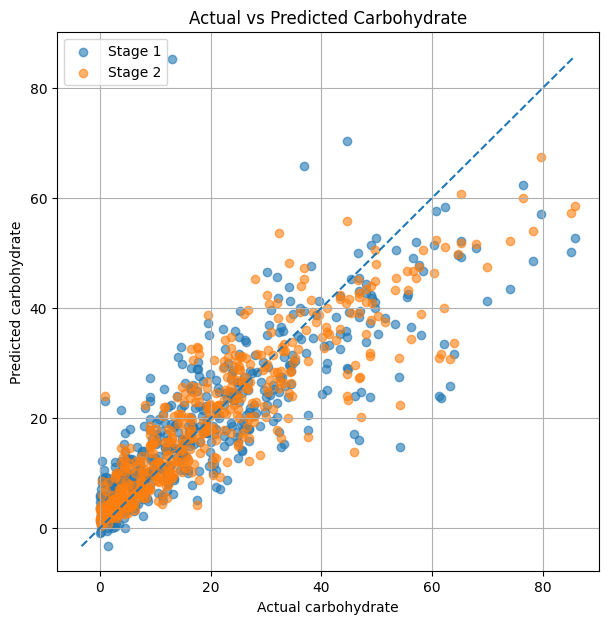

In [ ]:
plt.figure(figsize=(7, 7))
plt.scatter(
    comparison_predictions_df["total_carb"],
    comparison_predictions_df["pred_stage1"],
    alpha=0.6,
    label="Stage 1"
)
plt.scatter(
    comparison_predictions_df["total_carb"],
    comparison_predictions_df["pred_stage2"],
    alpha=0.6,
    label="Stage 2"
)

min_val = min(comparison_predictions_df["total_carb"].min(),
              comparison_predictions_df["pred_stage1"].min(),
              comparison_predictions_df["pred_stage2"].min())

max_val = max(comparison_predictions_df["total_carb"].max(),
              comparison_predictions_df["pred_stage1"].max(),
              comparison_predictions_df["pred_stage2"].max())

plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")
plt.xlabel("Actual carbohydrate")
plt.ylabel("Predicted carbohydrate")
plt.title("Actual vs Predicted Carbohydrate")
plt.legend()
plt.grid(True)
plt.show()